# Employee Attrition Analytics

## Module 8: Advanced Model Evaluation and Hyperparameter Tuning

### Objective

Improve and properly evaluate the machine learning models using cross-validation, ROC-AUC, and hyperparameter tuning.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

## Load ML-Ready Dataset

In [19]:
df = pd.read_csv("../data/processed/employee_attrition_ml_ready.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 52)


,Age,Gender,Experience,Salary,Performance_Score,Job_Satisfaction,Overtime,Work_Hours,Remote_Work,Training_Hours,Projects,Promotion_Last_5Yrs,Attrition,Manager_Rating,Sick_Leaves,Years_At_Company,Previous_Experience,Salary_Per_Experience,Workload_Score,Attrition_Target,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Data Analyst,Job_Role_DevOps Engineer,Job_Role_Financial Analyst,Job_Role_HR Executive,Job_Role_Marketing Specialist,Job_Role_Recruiter,Job_Role_SEO Executive,Job_Role_Sales Executive,Job_Role_Sales Manager,Job_Role_Software Engineer,Education_Master,Education_PhD,City_Islamabad,City_Karachi,City_Lahore,City_Peshawar,City_Rawalpindi,Employment_Type_Full-Time,Salary_Band_Medium,Salary_Band_High,Salary_Band_Very High,Experience_Band_Junior,Experience_Band_Mid Level,Experience_Band_Senior,Satisfaction_Category_Medium,Satisfaction_Category_High,Performance_Category_Average,Performance_Category_High
0,40.0,0,3,94113.0,5,6.0,1,46,0,70,5,No,No,5,6,14.6,0.0,31371.00,9.6,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1
1,39.0,1,2,54224.0,4,9.0,0,36,0,33,3,Yes,No,4,4,10.9,0.0,27112.00,6.6,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1
2,49.0,0,25,166749.0,2,6.0,0,48,1,75,12,No,No,8,2,11.7,13.3,6669.96,16.8,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0
3,54.0,1,26,196590.0,5,4.0,1,51,1,64,12,No,Yes,4,5,4.0,22.0,7561.15,17.1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1
4,41.0,1,18,231764.0,3,8.0,1,40,1,15,12,No,No,10,8,4.9,13.1,12875.78,16.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0


## Prepare Features and Target

In [20]:
X = df.drop(columns=["Attrition", "Attrition_Target"])

y = df["Attrition_Target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 50)
Target shape: (1000,)


## Check Feature Data Types

In [21]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['Promotion_Last_5Yrs']


In [22]:
X["Promotion_Last_5Yrs"] = X["Promotion_Last_5Yrs"].map({"No": 0, "Yes": 1})

In [23]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print(non_numeric_columns.tolist())

[]


## Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 50)
Testing data: (200, 50)


## Stratified 5-Fold Cross-Validation

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation folds:", cv.get_n_splits())

Cross-validation folds: 5


## Logistic Regression Cross-Validation

In [26]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_cv_scores = cross_val_score(
    logistic_model, X_train, y_train, cv=cv, scoring="f1"
)

print("F1 scores:", logistic_cv_scores)

print("Mean F1:", round(logistic_cv_scores.mean(), 4))

print("Standard deviation:", round(logistic_cv_scores.std(), 4))

/Users/huzaifa/Desktop/Huzaifa/Learning/DataScience/Projects/employee-attrition-analytics/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/huzaifa/Desktop/Huzaifa/Learning/DataScience/Projects/employee-attrition-analytics/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to imp

F1 scores: [0.47058824 0.73684211 0.7027027  0.64864865 0.74285714]
Mean F1: 0.6603
Standard deviation: 0.1006


/Users/huzaifa/Desktop/Huzaifa/Learning/DataScience/Projects/employee-attrition-analytics/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest Cross-Validation

In [27]:
random_forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)

forest_cv_scores = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring="f1")

print("F1 scores:", forest_cv_scores)

print("Mean F1:", round(forest_cv_scores.mean(), 4))

print("Standard deviation:", round(forest_cv_scores.std(), 4))

F1 scores: [0.7        0.8        0.76190476 0.71428571 0.64705882]
Mean F1: 0.7246
Standard deviation: 0.0525


## Cross-Validation Model Comparison

In [28]:
cv_results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "Mean_F1": [logistic_cv_scores.mean(), forest_cv_scores.mean()],
        "Std_F1": [logistic_cv_scores.std(), forest_cv_scores.std()],
    }
)

cv_results.round(4)

,Model,Mean_F1,Std_F1
0,Logistic Regression,0.6603,0.1006
1,Random Forest,0.7246,0.0525


## ROC-AUC Evaluation

In [29]:
logistic_model.fit(X_train, y_train)

random_forest.fit(X_train, y_train)

logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

forest_probabilities = random_forest.predict_proba(X_test)[:, 1]

logistic_auc = roc_auc_score(y_test, logistic_probabilities)

forest_auc = roc_auc_score(y_test, forest_probabilities)

print("Logistic Regression ROC-AUC:", round(logistic_auc, 4))
print("Random Forest ROC-AUC:", round(forest_auc, 4))

/Users/huzaifa/Desktop/Huzaifa/Learning/DataScience/Projects/employee-attrition-analytics/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression ROC-AUC: 0.9844
Random Forest ROC-AUC: 0.9813


## ROC Curves

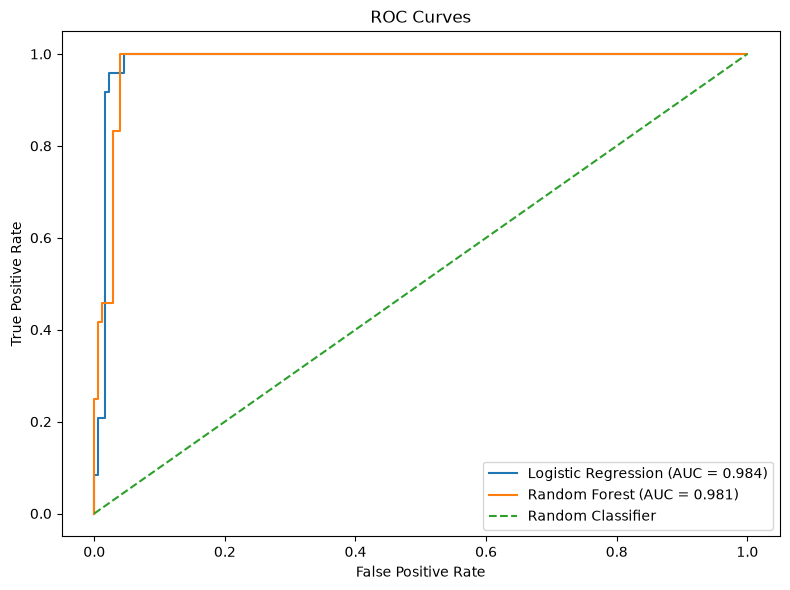

In [30]:
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probabilities)

forest_fpr, forest_tpr, _ = roc_curve(y_test, forest_probabilities)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr, logistic_tpr, label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(forest_fpr, forest_tpr, label=f"Random Forest (AUC = {forest_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

## Precision-Recall Curve

In [31]:
logistic_precision_curve, logistic_recall_curve, _ = precision_recall_curve(
    y_test, logistic_probabilities
)

forest_precision_curve, forest_recall_curve, _ = precision_recall_curve(
    y_test, forest_probabilities
)

logistic_ap = average_precision_score(y_test, logistic_probabilities)

forest_ap = average_precision_score(y_test, forest_probabilities)

print("Logistic Regression Average Precision:", round(logistic_ap, 4))

print("Random Forest Average Precision:", round(forest_ap, 4))

Logistic Regression Average Precision: 0.8205
Random Forest Average Precision: 0.8455


## Plot Precision-Recall Curves

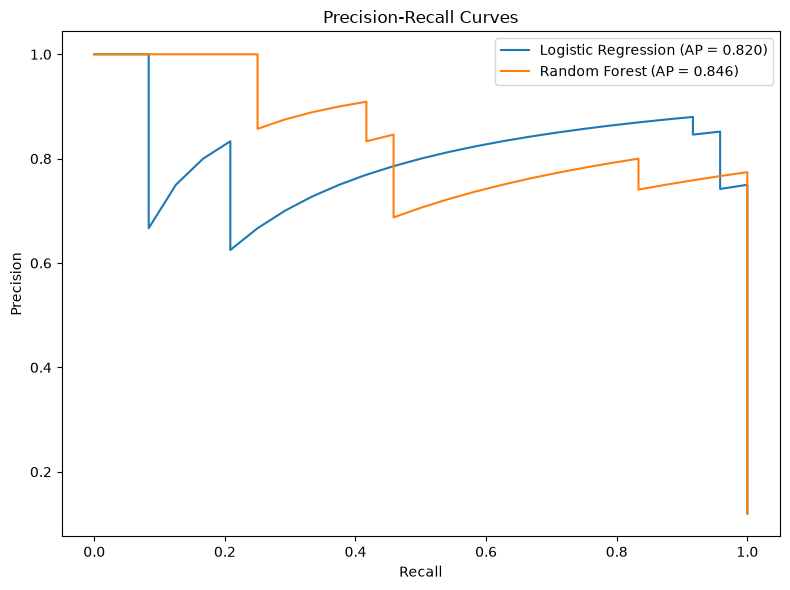

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall_curve,
    logistic_precision_curve,
    label=f"Logistic Regression (AP = {logistic_ap:.3f})",
)

plt.plot(
    forest_recall_curve,
    forest_precision_curve,
    label=f"Random Forest (AP = {forest_ap:.3f})",
)

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.tight_layout()
plt.show()

## Random Forest Hyperparameter Tuning

GridSearchCV evaluates multiple combinations of hyperparameters using cross-validation.

In [33]:
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

print("Number of parameter combinations:")
print(2 * 3 * 2 * 2)

Number of parameter combinations:
24


## Run Grid Search

In [ ]:
grid_search = GridSearchCV(
    estimator=rf_model, param_grid=param_grid, cv=cv, scoring="f1", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("Grid search completed successfully.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid search completed successfully.


## Best Random Forest Parameters

In [35]:
print("Best parameters:")

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

Best parameters:
max_depth: 12
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 100


## Best Cross-Validation Score

In [ ]:
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

Best CV F1 Score: 0.7502


## Retrieve Best Model

In [37]:
best_random_forest = grid_search.best_estimator_

print(best_random_forest)

RandomForestClassifier(max_depth=12, random_state=42)


## Evaluate Tuned Random Forest

In [38]:
y_pred_tuned = best_random_forest.predict(X_test)

y_prob_tuned = best_random_forest.predict_proba(X_test)[:, 1]

## Tuned Model Performance

In [39]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)

tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)

tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)

tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Random Forest")
print("=" * 35)

print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

Tuned Random Forest
Accuracy : 0.94
Precision: 0.7727
Recall   : 0.7083
F1 Score : 0.7391
ROC-AUC  : 0.9806


## Tuned Model Classification Report

In [ ]:
print(
    classification_report(
        y_test, y_pred_tuned, target_names=["Stayed", "Left"], zero_division=0
    )
)

              precision    recall  f1-score   support

      Stayed       0.96      0.97      0.97       176
        Left       0.77      0.71      0.74        24

    accuracy                           0.94       200
   macro avg       0.87      0.84      0.85       200
weighted avg       0.94      0.94      0.94       200



## Tuned Random Forest Confusion Matrix

In [41]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)

[[171   5]
 [  7  17]]


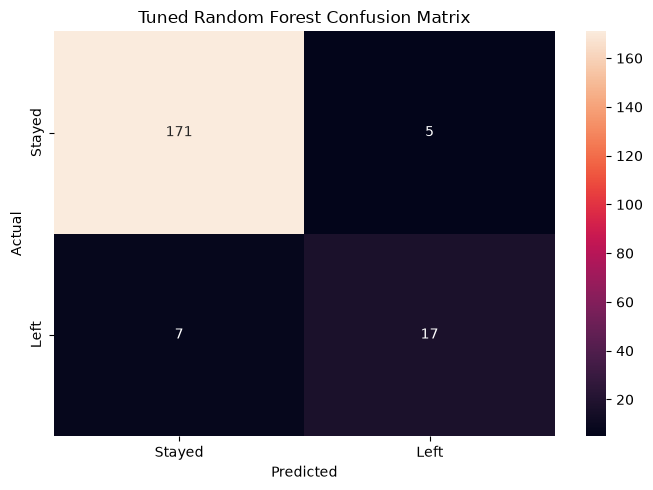

In [42]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"],
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


## Before vs After Hyperparameter Tuning

In [43]:
comparison = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        "Original Random Forest": [
            accuracy_score(y_test, random_forest.predict(X_test)),
            precision_score(y_test, random_forest.predict(X_test), zero_division=0),
            recall_score(y_test, random_forest.predict(X_test), zero_division=0),
            f1_score(y_test, random_forest.predict(X_test), zero_division=0),
            forest_auc,
        ],
        "Tuned Random Forest": [
            tuned_accuracy,
            tuned_precision,
            tuned_recall,
            tuned_f1,
            tuned_auc,
        ],
    }
)

comparison.round(4)

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.9350,0.9400
1,Precision,0.7619,0.7727
2,Recall,0.6667,0.7083
3,F1 Score,0.7111,0.7391
4,ROC-AUC,0.9813,0.9806


## Tuned Model Feature Importance

In [44]:
tuned_feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": best_random_forest.feature_importances_}
)

tuned_feature_importance = tuned_feature_importance.sort_values(
    by="Importance", ascending=False
)

tuned_feature_importance.head(15)

,Feature,Importance
5,Job_Satisfaction,0.364266
46,Satisfaction_Category_Medium,0.076959
6,Overtime,0.052969
47,Satisfaction_Category_High,0.052395
16,Salary_Per_Experience,0.035538
9,Training_Hours,0.034835
14,Years_At_Company,0.033453
0,Age,0.028477
3,Salary,0.026539
17,Workload_Score,0.025324


## Top 15 Features from Tuned Random Forest

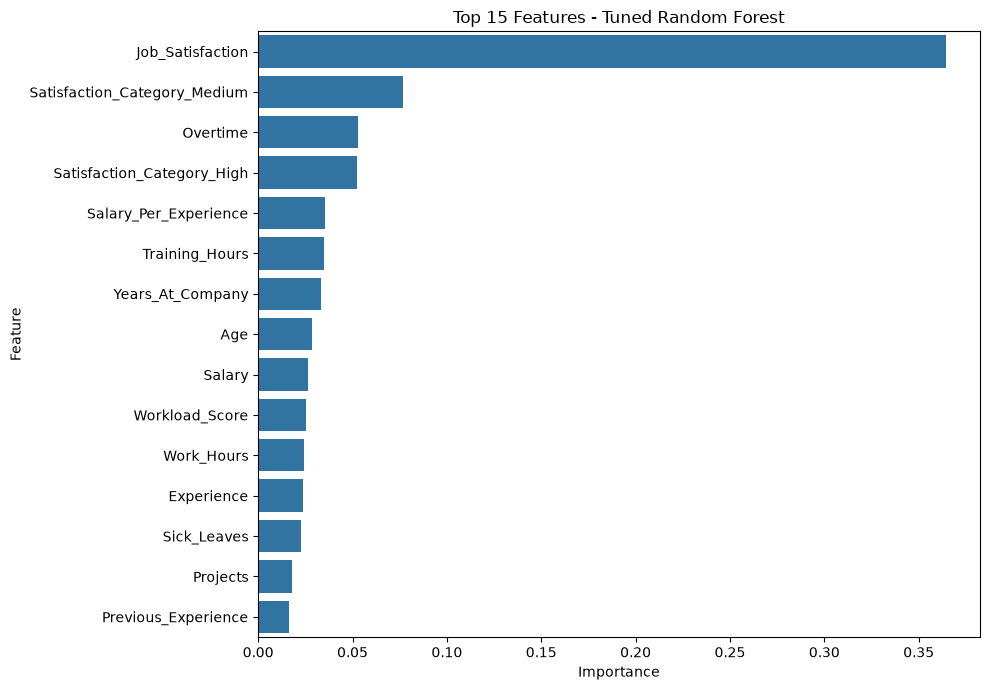

In [45]:
top_features = tuned_feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 15 Features - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Final Model Summary

In [46]:
print("FINAL MODEL SUMMARY")
print("=" * 50)

print("Model: Tuned Random Forest")

print(f"Accuracy : {tuned_accuracy:.4f}")

print(f"Precision: {tuned_precision:.4f}")

print(f"Recall   : {tuned_recall:.4f}")

print(f"F1 Score : {tuned_f1:.4f}")

print(f"ROC-AUC  : {tuned_auc:.4f}")

print(f"\nBest CV F1: {grid_search.best_score_:.4f}")

print("\nBest Parameters:")

for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

FINAL MODEL SUMMARY
Model: Tuned Random Forest
Accuracy : 0.9400
Precision: 0.7727
Recall   : 0.7083
F1 Score : 0.7391
ROC-AUC  : 0.9806

Best CV F1: 0.7502

Best Parameters:
  max_depth: 12
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100


## Save Hyperparameter Search Results

In [47]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results.to_csv(
    "../data/processed/random_forest_grid_search_results.csv", index=False
)

print("Grid search results saved successfully.")

Grid search results saved successfully.


## Save Tuned Feature Importance

In [48]:
tuned_feature_importance.to_csv(
    "../data/processed/tuned_feature_importance.csv", index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.
